# SPA613M Programming Assignment

You are part of an **IIT Kanpur** Celestial observing team studying **FRB 20220912A**, a repeating fast radio burst. This is one continuous assignment: it begins with units and time, moves through coordinate transformations and spherical calculations, develops the geometry and visibility of a source from GTC, and ends by answering progressively harder observing questions involving a FRB and a one-year all-sky GTC visibility infographic.

Use **UTC internally** for astronomical calculations. Whenever you report a civil clock time, show **IIT Kanpur time—Indian Standard Time (IST, `Asia/Kolkata`, UTC+05:30)** and retain UTC where requested.

**Total: 40 marks**  
**Optional:** Q20 carries 2 bonus marks.


## Marking Scheme

| Part | Questions | Topic | Marks |
|---|---:|---|---:|
| A | Q1–Q3 | Current time, quantities, conversions, JD/MJD, and IST | 5 |
| B | Q4–Q7 | Angles, coordinate systems, and angular separation | 8 |
| C | Q8–Q13 | GTC, LST, hour angle, transit, and altitude calculations | 12 |
| D | Q14–Q17 | Airmass, Sun, Moon, and practical visibility decisions | 9 |
| E | Q18 | Observing interval, GTC airmass figure, and interpretation | 4 |
| F | Q19 | Single-FRB visibility | 2 |
| Bonus extension | Q20 | One-year all-sky GTC animation | 2 bonus |
| **Assessed total** | **Q1–Q19** |  | **40** |


## Fixed target record

FRB 20220912A is a repeating fast radio burst. Use the following published VLBI position throughout the assignment:

- Source: `FRB 20220912A`
- ICRS/J2000 RA: `23h09m04.8989s`
- ICRS/J2000 Dec: `+48d42m23.9078s`
- Coordinate uncertainty: `5 mas`
- Dispersion measure: $219.46\,\mathrm{pc\,cm^{-3}}$
- Host redshift: $0.0771$

Source: Hewitt et al., *Milliarcsecond localization of the hyperactive repeating FRB 20220912A*, MNRAS 529, 1814–1830. The values above are frozen, so no catalogue or web query is required. [Published article](https://academic.oup.com/mnras/article/529/2/1814/7623035)

## Fixed GTC observing case

| Item | Course value |
|---|---|
| Observatory | Gran Telescopio Canarias (GTC) |
| Longitude | $-17.889^\circ$ |
| Latitude | $+28.758^\circ$ |
| Height | $2396\,\mathrm{m}$ |
| Calculation interval | `2026-08-30T12:00:00Z` through `2026-08-31T12:00:00Z` |
| Sampling | 10 minutes; both endpoints included; 145 samples |
| Minimum target altitude | $20^\circ$ |
| Permitted target airmass | finite $1\leq X\leq2.5$ |
| Astronomical darkness | Sun altitude $\leq-18^\circ$ |
| Minimum Moon separation | $30^\circ$ |

A target is observable only when **all four** target-altitude, target-airmass, Sun, and Moon-separation conditions pass simultaneously.

## Setup

Run the dependency cell before Q1. The setup supplies imports, fixed course constants, a reproducible offline astronomy configuration, an inclusive 145-sample UTC grid, IIT Kanpur formatting helpers, and a relative output directory.

In [1]:
import subprocess
import sys

REQUIRED_PACKAGES = [
    "numpy>=1.26",
    "matplotlib>=3.8",
    "astropy>=6.0",
    "astropy-iers-data",
    "tzdata",
    "healpy>=1.18",
    "astroplan>=0.10",
    "imageio>=2.31",
]

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--disable-pip-version-check",
        *REQUIRED_PACKAGES,
    ]
)
print("Dependencies installed: NumPy, Matplotlib, Astropy, IERS data, timezone data, healpy, astroplan, and imageio.")

Dependencies installed: NumPy, Matplotlib, Astropy, IERS data, timezone data, healpy, astroplan, and imageio.


In [2]:
from datetime import timezone
from pathlib import Path
from zoneinfo import ZoneInfo

import astropy
import matplotlib
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import healpy as hp
import numpy as np
from astropy import units as u
from astropy.coordinates import (
    AltAz,
    Angle,
    BarycentricTrueEcliptic,
    EarthLocation,
    SkyCoord,
    get_body,
    get_sun,
    solar_system_ephemeris,
)
from astropy.time import Time
from astropy.utils import iers
from astroplan import Observer

# Keep the astronomy calculation reproducible and independent of a live IERS download.
iers.conf.auto_download = False
iers.conf.auto_max_age = None

IITK_TIMEZONE = ZoneInfo("Asia/Kolkata")

FRB_NAME = "FRB 20220912A"
FRB_RA_J2000 = "23h09m04.8989s"
FRB_DEC_J2000 = "+48d42m23.9078s"
EARLIER_POSITION_RA = "23h09m04.9s"
EARLIER_POSITION_DEC = "+48d42m25.4s"

START_UTC = "2026-08-30T12:00:00"
STOP_UTC = "2026-08-31T12:00:00"
STEP_MINUTES = 10

GTC_LONGITUDE_DEG = -17.889
GTC_LATITUDE_DEG = 28.758
GTC_HEIGHT_M = 2396.0

MIN_TARGET_ALTITUDE_DEG = 20.0
MAX_AIRMASS = 2.5
MAX_SUN_ALTITUDE_DEG = -18.0
MIN_MOON_SEPARATION_DEG = 30.0

OUTPUT_DIR = Path("assignment_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# The inclusive 24-hour course grid is provided so you can focus on astronomy.
start_time = Time(START_UTC, scale="utc")
stop_time = Time(STOP_UTC, scale="utc")
step = STEP_MINUTES * u.min
number_of_steps = int(
    np.round(((stop_time - start_time) / step).to_value(u.dimensionless_unscaled))
)
times = start_time + np.arange(number_of_steps + 1) * step
assert len(times) == 145

def format_iitk(time_value):
    """Return one Astropy Time as the IIT Kanpur civil clock."""
    return time_value.to_datetime(timezone=IITK_TIMEZONE).strftime(
        "%Y-%m-%d %H:%M:%S IST"
    )

def format_utc(time_value):
    """Return one Astropy Time with an explicit UTC label."""
    return time_value.utc.strftime("%Y-%m-%d %H:%M:%S UTC")

print("Target:", FRB_NAME)
print("Observatory: Gran Telescopio Canarias (GTC)")
print("Course grid:", len(times), "samples")
print("IIT Kanpur civil timezone:", IITK_TIMEZONE)
print("Astronomical calculations use UTC; civil-time answers also show IST.")

Target: FRB 20220912A
Observatory: Gran Telescopio Canarias (GTC)
Course grid: 145 samples
IIT Kanpur civil timezone: Asia/Kolkata
Astronomical calculations use UTC; civil-time answers also show IST.


# Part A.  Astropy foundations: time, units, and conversions (5 marks)

## Q1. Current UTC and IIT Kanpur time [1 mark]

Call `Time.now()` exactly once and store it as `now`. Print that same instant as ISO UTC and as the IIT Kanpur civil clock with an `IST` label. In one sentence, explain why two separate calls to `Time.now()` need not describe exactly the same instant.

In [3]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
now = Time.now()
now_utc = now.utc
now_ist = now.to_datetime(timezone=IITK_TIMEZONE)
print("UTC :", now_utc.isot)
print("IST :", now_ist.strftime("%Y-%m-%d %H:%M:%S.%f IST"))
print("A separate Time.now() call would sample a later instant, even if only by a fraction of a second.")


UTC : 2026-09-06T15:25:24.609
IST : 2026-09-06 20:55:24.609463 IST
A separate Time.now() call would sample a later instant, even if only by a fraction of a second.


## Q2. Physical quantities and unit conversions [2 marks]

Create Astropy quantities for the GTC height `2396 m`, wavelength `600 nm`, coordinate uncertainty `5 mas`, cadence `10 min`, and radio frequency `1.4 GHz`. Convert them respectively to kilometres, frequency in THz using `u.spectral()`, arcseconds, hours, and wavelength in centimetres using `u.spectral()`. Print every original value beside its converted value.

In [4]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
height = 2396*u.m
wavelength = 600*u.nm
uncertainty = 5*u.mas
cadence = 10*u.min
frequency = 1.4*u.GHz
print(f"Height      :{height} -> {height.to(u.km)}")
print(f"Wavelength  :{wavelength} -> {wavelength.to(u.THz, equivalencies=u.spectral())}")
print(f"Uncertainty :{uncertainty} -> {uncertainty.to(u.arcsec)}")
print(f"Cadence     :{cadence} -> {cadence.to(u.hour)}")
print(f"Frequency   :{frequency} -> {frequency.to(u.cm, equivalencies=u.spectral())}")


Height      : 2396.0 m -> 2.396 km
Wavelength  : 600.0 nm -> 499.6540966666666 THz
Uncertainty : 5.0 mas -> 0.005 arcsec
Cadence     : 10.0 min -> 0.16666666666666666 h
Frequency   : 1.4 GHz -> 21.413747 cm


## Q3. UTC, JD, MJD, IST, and time arithmetic [2 marks]

Construct `planning_start = Time(START_UTC, scale="utc")`. Print UTC, Julian Date, Modified Julian Date, and IIT Kanpur time. Add `2.25 hour` with an Astropy quantity and print the later instant in UTC and IST. Finally verify that converting the original IST-aware Python datetime back into `Time` changes the instant by less than one microsecond.

In [5]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
planning_start = Time(START_UTC, scale="utc")
later = planning_start + 2.25 * u.hour

ist_dt = planning_start.to_datetime(timezone=IITK_TIMEZONE)
round_trip = Time(ist_dt)
print("Original UTC:", planning_start.utc.isot)
print("JD:", planning_start.jd)
print("MJD:", planning_start.mjd)
print("IST:", format_iitk(planning_start))
print("After +2.25 h UTC:", later.utc.isot)
print("After +2.25 h IST:", format_iitk(later))
difference_us = abs((round_trip - planning_start).to_value(u.s)) * 1e6
print(f"IST datetime round-trip difference: {difference_us:.6f} microsecond")
assert difference_us < 1.0


Original UTC: 2026-08-30T12:00:00.000
JD: 2461283.0
MJD: 61282.5
IST: 2026-08-30 17:30:00 IST
After +2.25 h UTC: 2026-08-30T14:15:00.000
After +2.25 h IST: 2026-08-30 19:45:00 IST
IST datetime round-trip difference: 0.000000 microsecond


# Part B. Angles and coordinate transformations (8 marks)


## Q4. Parse angles and construct an ICRS coordinate [2 marks]

Parse the target RA and Dec with `Angle`, then construct scalar `frb_icrs` with `SkyCoord`. Print RA and Dec in decimal degrees and padded sexagesimal notation. Verify RA $347.2704120833^\circ$ and Dec $+48.7066410556^\circ$ within $10^{-8}$ degree. Explain why RA commonly uses hours while Dec uses degrees.

In [6]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
ra_angle = Angle(FRB_RA_J2000, unit=u.hourangle)
dec_angle = Angle(FRB_DEC_J2000, unit=u.deg)
frb_icrs = SkyCoord(ra=ra_angle, dec=dec_angle, frame="icrs")

print("RA:", frb_icrs.ra.deg, "deg")
print("Dec:", frb_icrs.dec.deg, "deg")
print("RA (sexagesimal):", frb_icrs.ra.to_string(unit=u.hourangle, sep="hms", pad=True, precision=4))
print("Dec (sexagesimal):", frb_icrs.dec.to_string(unit=u.deg, sep="dms", alwayssign=True, pad=True, precision=4))
assert abs(frb_icrs.ra.deg - 347.2704120833) < 1e-8
assert abs(frb_icrs.dec.deg - 48.7066410556) < 1e-8
print("RA uses hours because 24 h of right ascension corresponds to one full 360° rotation; declination is measured directly as an angle on the celestial sphere.")


RA: 347.27041208333327 deg
Dec: 48.70664105555556 deg
RA (sexagesimal): 23h09m04.8989s
Dec (sexagesimal): +48d42m23.9078s
RA uses hours because 24 h of right ascension corresponds to one full 360° rotation; declination is measured directly as an angle on the celestial sphere.


## Q5. ICRS to Galactic and back [2 marks]

Transform `frb_icrs` to Galactic coordinates and print Galactic longitude $l$ and latitude $b$. Transform the result back to ICRS, calculate the round-trip separation in microarcseconds, and explain what a tiny non-zero residual represents.

In [7]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
frb_galactic = frb_icrs.galactic
roundtrip_gal = frb_galactic.transform_to("icrs")
gal_sep_uas = frb_icrs.separation(roundtrip_gal).to_value(u.microarcsecond)

print(f"Galactic longitude l = {frb_galactic.l.deg:.10f} deg")
print(f"Galactic latitude  b = {frb_galactic.b.deg:.10f} deg")
print(f"Round-trip separation = {gal_sep_uas:.6f} microarcsec")
print("A tiny residual is numerical/transform-rounding error, not a physical displacement of the source.")


Galactic longitude l = 106.0649607733 deg
Galactic latitude  b = -10.7841762854 deg
Round-trip separation = 0.000311 microarcsec
A tiny residual is numerical/transform-rounding error, not a physical displacement of the source.


## Q6. ICRS to Ecliptic and back [2 marks]

Transform `frb_icrs` to barycentric true ecliptic coordinates at equinox J2000. Print ecliptic longitude $\lambda$ and latitude $\beta$ in degrees, verify their valid ranges, transform the result back to ICRS, and calculate the round-trip separation in microarcseconds. Explain what the ecliptic plane and the value of $\beta$ mean physically.

In [8]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
ecliptic_frame = BarycentricTrueEcliptic(equinox=Time("J2000"))
frb_ecliptic = frb_icrs.transform_to(ecliptic_frame)
roundtrip_ecl = frb_ecliptic.transform_to("icrs")
ecl_sep_uas = frb_icrs.separation(roundtrip_ecl).to_value(u.microarcsecond)

lam = frb_ecliptic.lon.deg
beta = frb_ecliptic.lat.deg
print(f"Ecliptic longitude lambda = {lam:.10f} deg")
print(f"Ecliptic latitude  beta   = {beta:.10f} deg")
print(f"Round-trip separation = {ecl_sep_uas:.6f} microarcsec")
assert 0 <= lam < 360
assert -90 <= beta <= 90
print("The ecliptic plane is Earth's orbital plane projected onto the sky. Beta measures the angular distance north or south of that plane.")


Ecliptic longitude lambda = 14.4111876503 deg
Ecliptic latitude  beta   = 48.3469584374 deg
Round-trip separation = 0.000000 microarcsec
The ecliptic plane is Earth's orbital plane projected onto the sky. Beta measures the angular distance north or south of that plane.


## Q7. Angular separation [2 marks]

Construct `earlier_position` from `23h09m04.9s`, `+48d42m25.4s`. Calculate the great-circle separation manually from

$$\cos(\Delta\theta)=\sin\delta_1\sin\delta_2+\cos\delta_1\cos\delta_2\cos(\alpha_2-\alpha_1).$$

Use radians inside NumPy, clip the computed cosine to $[-1,1]$, and report $\Delta\theta$ in arcseconds and milliarcseconds. Compare with `frb_icrs.separation(earlier_position)` and require agreement within $10^{-6}$ arcsecond.

In [11]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
ra1 = frb_icrs.ra.to_value(u.rad)
dec1 = frb_icrs.dec.to_value(u.rad)
ra2 = earlier_position.ra.to_value(u.rad)
dec2 = earlier_position.dec.to_value(u.rad)

dra = ra2 - ra1
ddec = dec2 - dec1
a = (np.sin(ddec / 2.0) ** 2+ np.cos(dec1) * np.cos(dec2) * np.sin(dra / 2.0) ** 2)

theta = 2.0 * np.arcsin(np.sqrt(np.clip(a, 0.0, 1.0)))
theta_arcsec = np.degrees(theta) * 3600.0
theta_mas = theta_arcsec * 1000.0

astropy_arcsec = frb_icrs.separation(earlier_position).to_value(u.arcsec)
print(f"Manual separation : {theta_arcsec:.9f} arcsec = {theta_mas:.6f} mas")
print(f"Astropy separation : {astropy_arcsec:.9f} arcsec")
print(f"Absolute difference: {abs(theta_arcsec - astropy_arcsec):.3e} arcsec")

assert abs(theta_arcsec - astropy_arcsec) < 1e-6

Manual separation : 1.492239726 arcsec = 1492.239726 mas
Astropy separation : 1.492239726 arcsec
Absolute difference: 1.702e-11 arcsec


# Part C. GTC geometry, LST, transit, and altitude calculations (12 marks)

## Q8. Define the GTC observing site [1 mark]

Construct `gtc_location` with `EarthLocation.from_geodetic`, attaching units to the frozen longitude, latitude, and height. Print the recovered geodetic values. State what the negative longitude sign means.

In [12]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
gtc_location = EarthLocation.from_geodetic(
    lon=GTC_LONGITUDE_DEG * u.deg,
    lat=GTC_LATITUDE_DEG * u.deg,
    height=GTC_HEIGHT_M * u.m,)
lon, lat, height = gtc_location.to_geodetic()
print(f"Longitude: {lon.deg:.6f} deg")
print(f"Latitude : {lat.deg:.6f} deg")
print(f"Height   : {height.to_value(u.m):.2f} m")
print("The negative longitude means the observatory is east/west? It is west of the Greenwich meridian, so its longitude is conventionally negative.")


Longitude: -17.889000 deg
Latitude : 28.758000 deg
Height   : 2396.00 m
The negative longitude means the observatory is east/west? It is west of the Greenwich meridian, so its longitude is conventionally negative.


## Q9. Calculate GTC LST and hour angle at one instant [2 marks]

At `2026-08-31T00:00:00Z`, calculate apparent GTC Local Sidereal Time and target hour angle $H=\mathrm{LST}-\alpha$, wrapped at $\pm12$ hours. Print UTC, IIT Kanpur time, LST, and hour angle. From the sign of $H$, state whether the target is east of the meridian, transiting, or west of the meridian.

In [13]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
instant = Time("2026-08-31T00:00:00Z", scale="utc")
observer = Observer(location=gtc_location, name="GTC")
lst = observer.local_sidereal_time(instant, kind="apparent")
hour_angle = (lst - frb_icrs.ra).wrap_at(12 * u.hourangle)
print("UTC :", format_utc(instant))
print("IST :", format_iitk(instant))
print("LST :", lst.to_string(unit=u.hourangle, sep=":", precision=2))
print("H   :", hour_angle.to_string(unit=u.hourangle, sep=":", alwayssign=True, precision=2))
if hour_angle < 0*u.hourangle:
    position = "east of the meridian (approaching transit)"
elif hour_angle > 0*u.hourangle:
    position = "west of the meridian (after transit)"
else:
    position = "transiting"
print("Interpretation:", position)


UTC : 2026-08-31 00:00:00 UTC
IST : 2026-08-31 05:30:00 IST
LST : 21:25:12.21
H   : -1:43:52.69
Interpretation: east of the meridian (approaching transit)


## Q10. Find the nearest sampled meridian transit [2 marks]

Calculate apparent GTC LST and wrapped hour angle for all 145 samples. Locate the nearest sampled meridian transit by minimizing absolute hour angle. Print the sample index, UTC, IIT Kanpur time, LST, and hour angle. Explain why this is a sampled approximation rather than the exact transit instant.

In [14]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
lst_grid = observer.local_sidereal_time(times, kind="apparent")
hour_angles = (lst_grid - frb_icrs.ra).wrap_at(12 * u.hourangle)
ha_abs_hours = np.abs(hour_angles.to_value(u.hourangle))
transit_index = int(np.argmin(ha_abs_hours))
transit_time = times[transit_index]
print("Sample index:", transit_index)
print("UTC :", format_utc(transit_time))
print("IST :", format_iitk(transit_time))
print("LST :", lst_grid[transit_index].to_string(unit=u.hourangle, sep=":", precision=2))
print("H   :", hour_angles[transit_index].to_string(unit=u.hourangle, sep=":", alwayssign=True, precision=3))
print("This is only the nearest grid point because the schedule is sampled every 10 minutes; the exact zero-hour-angle instant can fall between samples.")


Sample index: 82
UTC : 2026-08-31 01:40:00 UTC
IST : 2026-08-31 07:10:00 IST
LST : 23:05:28.64
H   : -0:03:36.264
This is only the nearest grid point because the schedule is sampled every 10 minutes; the exact zero-hour-angle instant can fall between samples.


## Q11. Predict transit altitude and zenith distance [2 marks]

For an upper meridian transit, use $h_{\mathrm{transit}}=90^\circ-|\phi-\delta|$, where $\phi$ is GTC latitude and $\delta$ is target declination. Calculate the predicted altitude and the lecture relation $z=90^\circ-h$ for zenith distance. Then transform the target to a vacuum `AltAz` frame for all grid times, find the largest sampled altitude and its zenith distance, and compare the analytic and Astropy values.

In [15]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
phi = GTC_LATITUDE_DEG * u.deg
delta = frb_icrs.dec

predicted_altitude = 90*u.deg - abs(phi - delta)
predicted_zd = 90*u.deg - predicted_altitude

altaz_vacuum = AltAz(
    obstime=times,
    location=gtc_location,
    pressure=0 * u.hPa,)
frb_gtc_altaz = frb_icrs.transform_to(altaz_vacuum)
sampled_max_index = int(np.argmax(frb_gtc_altaz.alt))
sampled_max_altitude = frb_gtc_altaz.alt[sampled_max_index]
sampled_zd = 90*u.deg - sampled_max_altitude
print(f"Analytic transit altitude: {predicted_altitude.deg:.6f} deg")
print(f"Analytic zenith distance : {predicted_zd.deg:.6f} deg")
print(f"Maximum sampled altitude : {sampled_max_altitude.deg:.6f} deg")
print(f"Maximum sampled z        : {sampled_zd.deg:.6f} deg")
print(f"Difference               : {(sampled_max_altitude-predicted_altitude).to_value(u.arcsec):.3f} arcsec")


Analytic transit altitude: 70.051359 deg
Analytic zenith distance : 19.948641 deg
Maximum sampled altitude : 69.883913 deg
Maximum sampled z        : 20.116087 deg
Difference               : -602.806 arcsec


## Q12. Calculate altitude before, at, and after transit [3 marks]

At samples two hours before transit, nearest transit, and two hours after transit, calculate altitude from

$$\sin h=\sin\phi\sin\delta+\cos\phi\cos\delta\cos H.$$

Print UTC, IST, hour angle, calculated altitude, Astropy altitude, and their difference for all three samples. State the physical pattern you see as the source crosses the meridian.

In [19]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
offsets = np.array([-2, 0, 2]) * u.hour
requested_times = transit_time + offsets

requested_lst = observer.local_sidereal_time(requested_times, kind="apparent")
requested_H = (requested_lst - frb_icrs.ra).wrap_at(12 * u.hourangle)

phi_r = phi.to_value(u.rad)
dec_r = delta.to_value(u.rad)
for label, t, H in zip( ["2 h before", "transit sample", "2 h after"],requested_times,requested_H):
    H_r = H.to_value(u.rad)

    sin_h = (np.sin(phi_r) * np.sin(dec_r)+ np.cos(phi_r) * np.cos(dec_r) * np.cos(H_r))
    h_manual = np.arcsin(np.clip(sin_h, -1, 1)) * u.rad
    h_astropy = frb_icrs.transform_to(
        AltAz(obstime=t, location=gtc_location, pressure=0*u.hPa)).alt
   diff_arcsec = (h_manual - h_astropy).to_value(u.arcsec)

    print(
        f"{label:14s} | {format_utc(t)} | {format_iitk(t)} | "
        f"H={H.to_value(u.hourangle):+.3f} h | "
        f"manual={h_manual.to_value(u.deg):.5f} deg | "
        f"Astropy={h_astropy.to_value(u.deg):.5f} deg | "
        f"diff={diff_arcsec:.3e} arcsec"
    )

2 h before     | 2026-08-30 23:40:00 UTC | 2026-08-31 05:10:00 IST | H=-2.066 h | manual=59.03195 deg | Astropy=58.78158 deg | diff=9.013e+02 arcsec
transit sample | 2026-08-31 01:40:00 UTC | 2026-08-31 07:10:00 IST | H=-0.060 h | manual=70.03935 deg | Astropy=69.88391 deg | diff=5.596e+02 arcsec
2 h after      | 2026-08-31 03:40:00 UTC | 2026-08-31 09:10:00 IST | H=+1.945 h | manual=60.06304 deg | Astropy=60.16261 deg | diff=-3.584e+02 arcsec


## Q13. Calculate how long the source stays above 20 degrees [2 marks]

Solve the altitude equation for the limiting hour angle:

$$\cos H_0=\frac{\sin h_{\min}-\sin\phi\sin\delta}{\cos\phi\cos\delta}.$$

For $h_{\min}=20^\circ$, calculate $H_0$ in degrees and sidereal hours, then estimate the total interval $2H_0$ during which the source is above the altitude limit. Compare this with the number of grid samples above $20^\circ$.

In [20]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
hmin = MIN_TARGET_ALTITUDE_DEG * u.deg
numerator = np.sin(hmin.to_value(u.rad)) - np.sin(phi_r)*np.sin(dec_r)
denominator = np.cos(phi_r)*np.cos(dec_r)
cos_H0 = np.clip(numerator/denominator, -1, 1)
H0 = np.arccos(cos_H0) * u.rad
H0_deg = H0.to_value(u.deg)
H0_sidereal_h = H0.to_value(u.hourangle)
duration_hours = 2 * H0_sidereal_h

sampled_above = frb_gtc_altaz.alt >= hmin
print(f"Limiting |H0| = {H0_deg:.6f} deg = {H0_sidereal_h:.6f} sidereal h")
print(f"Analytic time above {MIN_TARGET_ALTITUDE_DEG:.0f} deg ≈ {duration_hours:.6f} sidereal h")
print("Grid samples above 20 deg:", int(np.count_nonzero(sampled_above)))
print(f"Grid span represented by those samples: {np.count_nonzero(sampled_above)*STEP_MINUTES/60:.3f} h (sample-centre count)")


Limiting |H0| = 91.927477 deg = 6.128498 sidereal h
Analytic time above 20 deg ≈ 12.256997 sidereal h
Grid samples above 20 deg: 74
Grid span represented by those samples: 12.333 h (sample-centre count)


# Part D. Airmass, Sun, Moon, and practical visibility (9 marks)

## Q14. Calculate a physically safe target airmass [2 marks]

Convert `frb_gtc_altaz.secz` to a float array named `target_airmass`. Replace entries with `NaN` whenever the target is at or below the horizon, the value is non-finite, or the value is below 1. Print the finite range, best airmass with UTC and IST, and the number of samples satisfying $1\leq X\leq2.5$. Explain why below-horizon values must not be used.

In [21]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
target_airmass = np.asarray(frb_gtc_altaz.secz.value, dtype=float)
bad = (
    (frb_gtc_altaz.alt.to_value(u.deg) <= 0)
    | (~np.isfinite(target_airmass))
    | (target_airmass < 1)
)
target_airmass[bad] = np.nan

finite = np.isfinite(target_airmass)
best_index = int(np.nanargmin(target_airmass))
acceptable = finite & (target_airmass >= 1) & (target_airmass <= MAX_AIRMASS)
print(f"Finite airmass range: {np.nanmin(target_airmass):.4f} to {np.nanmax(target_airmass):.4f}")
print(f"Best airmass: X={target_airmass[best_index]:.4f} at {format_utc(times[best_index])} / {format_iitk(times[best_index])}")
print(f"Samples with 1 <= X <= {MAX_AIRMASS}: {int(np.count_nonzero(acceptable))}")
print("Below-horizon sec(z) values are not physical observing airmasses; using them would treat an unavailable line of sight as a usable atmospheric path.")


Finite airmass range: 1.0650 to 55.3385
Best airmass: X=1.0650 at 2026-08-31 01:40:00 UTC / 2026-08-31 07:10:00 IST
Samples with 1 <= X <= 2.5: 68
Below-horizon sec(z) values are not physical observing airmasses; using them would treat an unavailable line of sight as a usable atmospheric path.


### Moon-conditions

Use the following simplified **course classification**. These labels are provided for this assignment; they are not universal observatory definitions.

| Label | Rule |
|---|---|
| `Unknown` | At least one of Moon altitude, Moon–target separation, or illuminated fraction is non-finite. |
| `Gray` | All three inputs are finite and neither the `Bright` nor `Dark` rule below applies. |
| `Bright` | The illuminated fraction is at least 0.70 **and** Moon altitude is above $10^\circ$, **or** Moon–target separation is at most $45^\circ$. |
| `Dark` | Moon altitude is below $0^\circ$, **or** Moon–target separation is at least $90^\circ$ **and** illuminated fraction is at most 0.25. |

Apply `Bright` first and `Dark` second. Therefore, if both rules happen to pass, the final label is `Dark`.

## Q15. Calculate Sun and Moon observing conditions [2 marks]

Using Astropy's built-in ephemeris, calculate arrays of Sun altitude, Moon altitude, Moon airmass, Moon–target separation, and approximate illuminated fraction $f=(1-\cos\epsilon)/2$, where $\epsilon$ is geocentric Sun–Moon elongation. Keep Moon airmass only from 1 to 3 and above the horizon. Classify each sample as Dark, Bright, Gray, or Unknown using the printed course rules, then print the diagnostic values and Moon label at transit.

In [22]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
sun_altaz = get_sun(times).transform_to(AltAz(obstime=times, location=gtc_location, pressure=0*u.hPa))
with solar_system_ephemeris.set("builtin"):
    moon_coord = get_body("moon", times, location=gtc_location)

moon_altaz = moon_coord.transform_to(AltAz(obstime=times, location=gtc_location, pressure=0*u.hPa))
moon_airmass = np.asarray(moon_altaz.secz.value, dtype=float)
moon_airmass[(moon_altaz.alt.to_value(u.deg) <= 0) | (~np.isfinite(moon_airmass)) | (moon_airmass < 1) | (moon_airmass > 3)] = np.nan
moon_target_sep = moon_coord.separation(frb_icrs).to_value(u.deg)
sun_geocentric = get_sun(times)
moon_geocentric = get_body("moon", times)
elongation = sun_geocentric.separation(moon_geocentric)
illuminated_fraction = (1 - np.cos(elongation.to_value(u.rad))) / 2
moon_label = np.full(len(times), "Gray", dtype=object)
finite_inputs = (
    np.isfinite(moon_altaz.alt.to_value(u.deg))
    & np.isfinite(moon_target_sep)
    & np.isfinite(illuminated_fraction)
)
moon_label[~finite_inputs] = "Unknown"

bright = finite_inputs & (
    ((illuminated_fraction >= 0.70) & (moon_altaz.alt.to_value(u.deg) > 10))
    | (moon_target_sep <= 45)
)
dark = finite_inputs & (
    (moon_altaz.alt.to_value(u.deg) < 0)
    | ((moon_target_sep >= 90) & (illuminated_fraction <= 0.25))
)
moon_label[bright] = "Bright"
moon_label[dark] = "Dark"

print("UTC | Sun alt | Moon alt | Moon X | Moon-target sep | illum. frac | label")
for i in range(len(times)):
    print(f"{format_utc(times[i])} | {sun_altaz.alt[i].deg:7.2f} | {moon_altaz.alt[i].deg:8.2f} | "
          f"{moon_airmass[i]:6.3f} | {moon_target_sep[i]:8.2f} | {illuminated_fraction[i]:.3f} | {moon_label[i]}")
print(f"At nearest sampled transit ({format_utc(transit_time)}): Moon label = {moon_label[transit_index]}, "
      f"Moon altitude = {moon_altaz.alt[transit_index].deg:.2f} deg, separation = {moon_target_sep[transit_index]:.2f} deg, "
      f"illumination = {illuminated_fraction[transit_index]:.3f}")


 '2026-08-30T12:20:00.000' '2026-08-30T12:30:00.000'
 '2026-08-30T12:40:00.000' '2026-08-30T12:50:00.000'
 '2026-08-30T13:00:00.000' '2026-08-30T13:10:00.000'
 '2026-08-30T13:20:00.000' '2026-08-30T13:30:00.000'
 '2026-08-30T13:40:00.000' '2026-08-30T13:50:00.000'
 '2026-08-30T14:00:00.000' '2026-08-30T14:10:00.000'
 '2026-08-30T14:20:00.000' '2026-08-30T14:30:00.000'
 '2026-08-30T14:40:00.000' '2026-08-30T14:50:00.000'
 '2026-08-30T15:00:00.000' '2026-08-30T15:10:00.000'
 '2026-08-30T15:20:00.000' '2026-08-30T15:30:00.000'
 '2026-08-30T15:40:00.000' '2026-08-30T15:50:00.000'
 '2026-08-30T16:00:00.000' '2026-08-30T16:10:00.000'
 '2026-08-30T16:20:00.000' '2026-08-30T16:30:00.000'
 '2026-08-30T16:40:00.000' '2026-08-30T16:50:00.000'
 '2026-08-30T17:00:00.000' '2026-08-30T17:10:00.000'
 '2026-08-30T17:20:00.000' '2026-08-30T17:30:00.000'
 '2026-08-30T17:40:00.000' '2026-08-30T17:50:00.000'
 '2026-08-30T18:00:00.000' '2026-08-30T18:10:00.000'
 '2026-08-30T18:20:00.000' '2026-08-30T18:30:0

UTC | Sun alt | Moon alt | Moon X | Moon-target sep | illum. frac | label
2026-08-30 12:00:00 UTC |   63.88 |   -37.68 |    nan |    46.38 | 0.941 | Dark
2026-08-30 12:10:00 UTC |   65.33 |   -39.41 |    nan |    46.37 | 0.940 | Dark
2026-08-30 12:20:00 UTC |   66.65 |   -41.09 |    nan |    46.36 | 0.940 | Dark
2026-08-30 12:30:00 UTC |   67.79 |   -42.72 |    nan |    46.34 | 0.940 | Dark
2026-08-30 12:40:00 UTC |   68.73 |   -44.30 |    nan |    46.33 | 0.939 | Dark
2026-08-30 12:50:00 UTC |   69.44 |   -45.81 |    nan |    46.32 | 0.939 | Dark
2026-08-30 13:00:00 UTC |   69.91 |   -47.25 |    nan |    46.31 | 0.939 | Dark
2026-08-30 13:10:00 UTC |   70.11 |   -48.61 |    nan |    46.30 | 0.938 | Dark
2026-08-30 13:20:00 UTC |   70.02 |   -49.89 |    nan |    46.29 | 0.938 | Dark
2026-08-30 13:30:00 UTC |   69.67 |   -51.08 |    nan |    46.27 | 0.937 | Dark
2026-08-30 13:40:00 UTC |   69.06 |   -52.16 |    nan |    46.26 | 0.937 | Dark
2026-08-30 13:50:00 UTC |   68.21 |   -53.13 |

## Q16. Implement the visibility function [3 marks]

Write exactly

```python
visibility(altitude, airmass, sun_altitude, moon_separation)
```

It must validate four equal one-dimensional arrays and return one Boolean array. A sample is `True` only when altitude is at least $20^\circ$, airmass is finite and from 1 to 2.5, Sun altitude is at most $-18^\circ$, and Moon separation is at least $30^\circ$. Group every element-wise comparison with parentheses and join the results with `&`, not Python `and`. Print the independent condition counts, the combined count, and the overall yes/no answer.

In [23]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
def visibility(altitude, airmass, sun_altitude, moon_separation):
    altitude = np.asarray(altitude, dtype=float)
    airmass = np.asarray(airmass, dtype=float)
    sun_altitude = np.asarray(sun_altitude, dtype=float)
    moon_separation = np.asarray(moon_separation, dtype=float)
    arrays = [altitude, airmass, sun_altitude, moon_separation]
    if any(a.ndim != 1 for a in arrays):
        raise ValueError("All inputs must be one-dimensional.")
    if len({a.size for a in arrays}) != 1:
        raise ValueError("All inputs must have equal length.")
    return (
        (altitude >= MIN_TARGET_ALTITUDE_DEG)
        & (np.isfinite(airmass))
        & (airmass >= 1)
        & (airmass <= MAX_AIRMASS)
        & (sun_altitude <= MAX_SUN_ALTITUDE_DEG)
        & (moon_separation >= MIN_MOON_SEPARATION_DEG)
    )

target_altitude = frb_gtc_altaz.alt.to_value(u.deg)
sun_altitude = sun_altaz.alt.to_value(u.deg)
visibility_state = visibility(target_altitude, target_airmass, sun_altitude, moon_target_sep)
preferred_visibility = visibility_state
print("Altitude condition :", int(np.count_nonzero(target_altitude >= MIN_TARGET_ALTITUDE_DEG)))
print("Airmass condition  :", int(np.count_nonzero(np.isfinite(target_airmass) & (target_airmass >= 1) & (target_airmass <= MAX_AIRMASS))))
print("Darkness condition :", int(np.count_nonzero(sun_altitude <= MAX_SUN_ALTITUDE_DEG)))
print("Moon separation    :", int(np.count_nonzero(moon_target_sep >= MIN_MOON_SEPARATION_DEG)))
print("Combined visible   :", int(np.count_nonzero(preferred_visibility)))
print("Overall visibility :", "YES" if np.any(preferred_visibility) else "NO")


Altitude condition : 74
Airmass condition  : 68
Darkness condition : 51
Moon separation    : 145
Combined visible   : 51
Overall visibility : YES


## Q17. Does transit automatically mean visible? [2 marks]

Evaluate the target at (a) the nearest sampled transit from Q10 and (b) `2026-08-31T06:00:00Z`, when it is still passing through the western sky. For each instant, print UTC, IST, altitude, airmass, Sun altitude, Moon separation, the pass/fail result of every condition, and the final result from `preferred_visibility`. Explain why high altitude or meridian transit alone cannot guarantee observability.

In [24]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
def report_visibility_at(t):
    target = frb_icrs.transform_to(AltAz(obstime=t, location=gtc_location, pressure=0*u.hPa))
    sun = get_sun(t).transform_to(AltAz(obstime=t, location=gtc_location, pressure=0*u.hPa))
    with solar_system_ephemeris.set("builtin"):
        moon = get_body("moon", t, location=gtc_location)
    moon_alt = moon.transform_to(AltAz(obstime=t, location=gtc_location, pressure=0*u.hPa))
    x = float(target.secz.value) if target.alt.deg > 0 and np.isfinite(target.secz.value) else np.nan
    sep = float(moon.separation(frb_icrs).deg)

    checks = {
        "altitude >= 20": bool(target.alt.deg >= MIN_TARGET_ALTITUDE_DEG),
        "1 <= airmass <= 2.5": bool(np.isfinite(x) and 1 <= x <= MAX_AIRMASS),
        "Sun <= -18": bool(sun.alt.deg <= MAX_SUN_ALTITUDE_DEG),
        "Moon separation >= 30": bool(sep >= MIN_MOON_SEPARATION_DEG),
    }
    final = all(checks.values())
    print("\n", format_utc(t), "/", format_iitk(t))
    print(f"Altitude={target.alt.deg:.3f} deg, airmass={x:.3f}, Sun altitude={sun.alt.deg:.3f} deg, Moon separation={sep:.3f} deg")
    for name, passed in checks.items():
        print(f"{name:25s}: {'PASS' if passed else 'FAIL'}")
    print("preferred_visibility:", final)
    return final

report_visibility_at(transit_time)
report_visibility_at(Time("2026-08-31T06:00:00Z", scale="utc"))
print("Transit controls the geometric altitude, but observability also requires darkness, an acceptable atmospheric path length, and sufficient Moon-target separation.")



 2026-08-31 01:40:00 UTC / 2026-08-31 07:10:00 IST
Altitude=69.884 deg, airmass=1.065, Sun altitude=-51.956 deg, Moon separation=45.227 deg
altitude >= 20           : PASS
1 <= airmass <= 2.5      : PASS
Sun <= -18               : PASS
Moon separation >= 30    : PASS
preferred_visibility: True

 2026-08-31 06:00:00 UTC / 2026-08-31 11:30:00 IST
Altitude=37.986 deg, airmass=1.625, Sun altitude=-11.282 deg, Moon separation=44.698 deg
altitude >= 20           : PASS
1 <= airmass <= 2.5      : PASS
Sun <= -18               : FAIL
Moon separation >= 30    : PASS
preferred_visibility: False
Transit controls the geometric altitude, but observability also requires darkness, an acceptable atmospheric path length, and sufficient Moon-target separation.


# Part E. Observing and scheduling GTC (4 marks)

## Q18. Report the observing interval and make GTC airmass figure [4 marks]

Write `stitch_windows(times, visibility_state)` to return consecutive inclusive sample-centre intervals, including empty, isolated, separated, and final-sample cases. Apply it to `preferred_visibility`. Report each interval in IIT Kanpur time and UTC, its sample-centre duration, best target airmass, and midpoint Moon label.

Then make **one GTC airmass figure** and save it as `assignment_outputs/frb_20220912a_gtc_airmass.png`. Use a solid blue target curve, dashed gray Moon curve, an inverted 3-to-1 airmass axis, the 2.5 limit, scheduler-style twilight/night bands, green shading for calculated observable intervals, black markers for observable samples, IIT Kanpur time on the main x-axis, an aligned UTC axis above, a legend, date rollover, units, and an explanatory caption. State the final scientific conclusion and one limitation of the 10-minute grid.

Observable windows:
2026-08-31 02:30:00 IST -> 2026-08-31 10:50:00 IST | 2026-08-30 21:00:00 UTC -> 2026-08-31 05:20:00 UTC | sample-centre duration=8.333 h | best X=1.065 | midpoint Moon=Bright


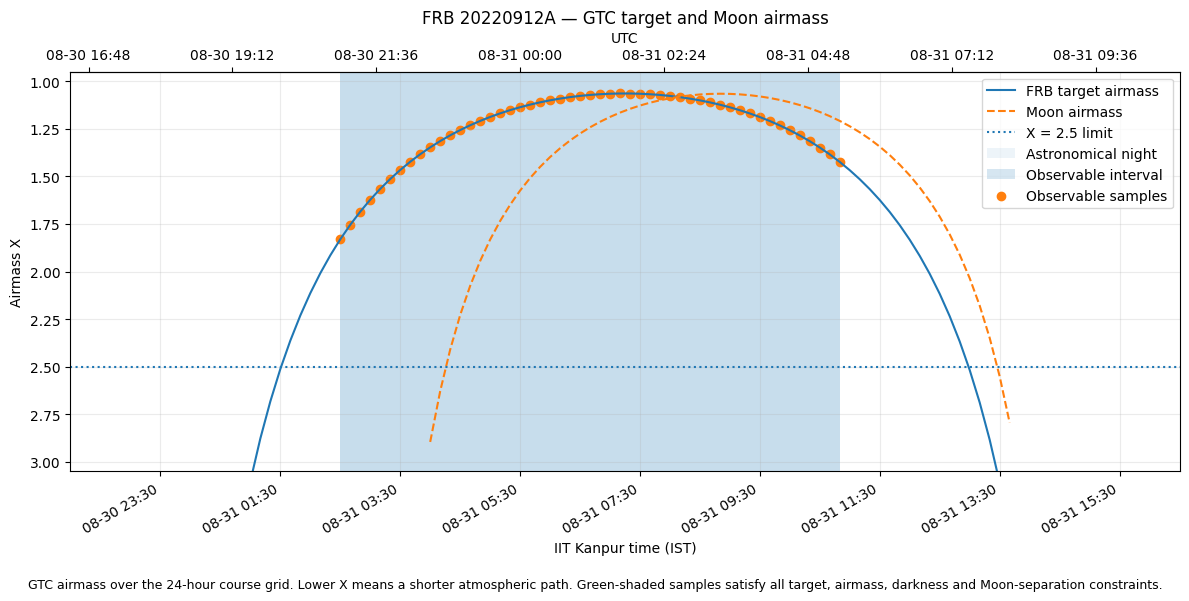

Saved: assignment_outputs/frb_20220912a_gtc_airmass.png size: 164296 bytes
Conclusion: only samples satisfying every constraint are scheduler-usable; the 10-minute cadence can shift reported boundaries by up to roughly one sample.


In [25]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
def stitch_windows(times, visibility_state):
    t = list(times)
    state = np.asarray(visibility_state, dtype=bool)
    if state.ndim != 1 or len(t) != state.size:
        raise ValueError("times and visibility_state must be one-dimensional and equal in length.")
    windows = []
    start = None
    for i, is_visible in enumerate(state):
        if is_visible and start is None:
            start = i
        if start is not None and (not is_visible or i == len(state)-1):
            end = i if is_visible else i - 1
            windows.append((t[start], t[end], start, end))
            start = None
    return windows

windows = stitch_windows(times, preferred_visibility)
print("Observable windows:")
for start, end, i0, i1 in windows:
    duration = (end - start).to_value(u.min)
    best_local = i0 + int(np.nanargmin(target_airmass[i0:i1+1]))
    midpoint = i0 + (i1-i0)//2
    print(f"{format_iitk(start)} -> {format_iitk(end)} | {format_utc(start)} -> {format_utc(end)} | "
          f"sample-centre duration={(duration/60):.3f} h | best X={target_airmass[best_local]:.3f} | "
          f"midpoint Moon={moon_label[midpoint]}")

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(times.to_datetime(), target_airmass, label="FRB target airmass")
ax.plot(times.to_datetime(), moon_airmass, "--", label="Moon airmass")
ax.axhline(MAX_AIRMASS, linestyle=":", label="X = 2.5 limit")
ax.set_ylim(3.05, 0.95)
ax.set_ylabel("Airmass X")
ax.set_xlabel("IIT Kanpur time (IST)")
ax.grid(alpha=0.25)

# Twilight/night bands
xdt = times.to_datetime(timezone=IITK_TIMEZONE)
night = sun_altitude <= MAX_SUN_ALTITUDE_DEG
ax.fill_between(xdt, 0.95, 3.05, where=night, alpha=0.08, label="Astronomical night")
for start, end, i0, i1 in windows:
    ax.axvspan(xdt[i0], xdt[i1], alpha=0.18, label="Observable interval" if i0 == windows[0][2] else None)

visible_idx = np.flatnonzero(preferred_visibility)
ax.scatter(xdt[visible_idx], target_airmass[visible_idx], marker="o", label="Observable samples")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M", tz=IITK_TIMEZONE))
ax.legend()
ax.set_title("FRB 20220912A — GTC target and Moon airmass")
fig.autofmt_xdate()

secax = ax.secondary_xaxis("top")
secax.set_xlabel("UTC")
secax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M", tz=timezone.utc))

caption = ("GTC airmass over the 24-hour course grid. Lower X means a shorter atmospheric path. "
           "Green-shaded samples satisfy all target, airmass, darkness and Moon-separation constraints.")
fig.text(0.5, 0.01, caption, ha="center", fontsize=9)
fig.tight_layout(rect=(0, 0.04, 1, 1))
out_plot = OUTPUT_DIR / "frb_20220912a_gtc_airmass.png"
fig.savefig(out_plot, dpi=160, bbox_inches="tight")
plt.show()
print("Saved:", out_plot, "size:", out_plot.stat().st_size, "bytes")
print("Conclusion: only samples satisfying every constraint are scheduler-usable; the 10-minute cadence can shift reported boundaries by up to roughly one sample.")


# Part F. All-sky observability (2 assessed marks + 2 optional bonus marks)

The previous parts established the physical ingredients needed for an observing decision. The next questions reuse those same ideas at increasing scale: first one source on one date, then a weekly all-sky GTC visibility animation over one year.

For Q19–Q20, use the geometric/airmass GTC visibility rule developed in the notebook: the source or sky position must be above the horizon, satisfy the GTC airmass limit, and be inside astronomical night. Do not include the Moon in these questions.


## Q19. Find the GTC visibility window of the repeating FRB on one date [2 marks]

Treat FRB 20220912A as a repeating source at its fixed ICRS/J2000 position. For `2026-09-01`, calculate its visibility from GTC across the full UTC day using the same HEALPix-style visibility logic: astronomical night, target altitude above the horizon, and target airmass no larger than 2.5. Report the start and end of each contiguous visibility interval in UTC and IIT Kanpur time, together with the total visible duration in hours.

This is a **single source**, not an all-sky calculation.


In [26]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
day_start = Time("2026-09-01T00:00:00Z", scale="utc")
day_times = day_start + np.arange(145) * (10*u.min)

day_target = frb_icrs.transform_to(AltAz(obstime=day_times, location=gtc_location, pressure=0*u.hPa))
day_sun = get_sun(day_times).transform_to(AltAz(obstime=day_times, location=gtc_location, pressure=0*u.hPa))
day_airmass = np.asarray(day_target.secz.value, dtype=float)
day_airmass[(day_target.alt.deg <= 0) | (~np.isfinite(day_airmass)) | (day_airmass < 1)] = np.nan

day_visible = (
    (day_target.alt.deg >= MIN_TARGET_ALTITUDE_DEG)
    & np.isfinite(day_airmass)
    & (day_airmass <= MAX_AIRMASS)
    & (day_sun.alt.deg <= MAX_SUN_ALTITUDE_DEG)
)

day_windows = stitch_windows(day_times, day_visible)
print("FRB 20220912A visibility on 2026-09-01:")
total = 0.0
for start, end, _, _ in day_windows:
    duration_h = (end-start).to_value(u.hour)
    total += duration_h
    print(f"{format_utc(start)} -> {format_utc(end)} | {format_iitk(start)} -> {format_iitk(end)} | {duration_h:.3f} h")
print(f"Total visible sample-centre duration: {total:.3f} h")


FRB 20220912A visibility on 2026-09-01:
2026-09-01 00:00:00 UTC -> 2026-09-01 05:20:00 UTC | 2026-09-01 05:30:00 IST -> 2026-09-01 10:50:00 IST | 5.333 h
2026-09-01 21:00:00 UTC -> 2026-09-02 00:00:00 UTC | 2026-09-02 02:30:00 IST -> 2026-09-02 05:30:00 IST | 3.000 h
Total visible sample-centre duration: 8.333 h


## Q20. Generate a one-year GTC visibility animation [2 bonus marks]

Use the same **all-sky GTC visibility** model over the next year, starting on **2026-08-30** and sampled every 7 days. With a weekly cadence, the final sample within the 365-day window is **2027-08-29**. For each date, compute the HEALPix visibility map using the same GTC astronomical-night, altitude, and airmass conditions developed earlier.

Save each weekly map as a PNG frame and combine the frames into a GIF. The animation should show how the observable sky from GTC changes through the year. Use a moderate HEALPix resolution so that the calculation is practical.

Briefly describe what changes across the animation and why the observable region changes with date.

In [27]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
nside = 16
npix = hp.nside2npix(nside)
theta, phi_hp = hp.pix2ang(nside, np.arange(npix))
sky_ra = np.degrees(phi_hp)
sky_dec = 90 - np.degrees(theta)
sky = SkyCoord(ra=sky_ra*u.deg, dec=sky_dec*u.deg, frame="icrs")

weekly_dates = [Time("2026-08-30T00:00:00Z") + i*u.day for i in range(0, 365, 7)]
frame_dir = OUTPUT_DIR / "q20_frames"
frame_dir.mkdir(parents=True, exist_ok=True)
gif_path = OUTPUT_DIR / "frb_20220912a_gtc_visibility_year.gif"

# Twelve 2-hour samples per day are sufficient to show the seasonal pattern.
intraday = np.arange(0, 24, 0.5) * u.hour
frame_paths = []

for k, d in enumerate(weekly_dates):
    sample_times = d + intraday
    frame_observer = AltAz(obstime=sample_times, location=gtc_location, pressure=0*u.hPa)
    sky_altaz = sky[:, None].transform_to(frame_observer)

    sky_x = np.asarray(sky_altaz.secz.value, dtype=float)
    sun_alt = get_sun(sample_times).transform_to(frame_observer).alt.to_value(u.deg)

    visible = (
        (sky_altaz.alt.to_value(u.deg) >= MIN_TARGET_ALTITUDE_DEG)
        & np.isfinite(sky_x)
        & (sky_x >= 1)
        & (sky_x <= MAX_AIRMASS)
        & (sun_alt[None, :] <= MAX_SUN_ALTITUDE_DEG)
    )
    visibility_hours = visible.sum(axis=1) * 0.5

    # Mollweide expects radians. Roll longitude to place 0° near the centre.
    ra_plot = np.radians(((sky_ra + 180) % 360) - 180)
    dec_plot = np.radians(sky_dec)

    fig = plt.figure(figsize=(10, 5.5))
    ax = fig.add_subplot(111, projection="mollweide")
    im = ax.scatter(ra_plot, dec_plot, c=visibility_hours, s=3, rasterized=True)
    ax.grid(alpha=0.25)
    ax.set_title(f"GTC observable time — {d.utc.strftime('%Y-%m-%d')}")
    cbar = fig.colorbar(im, ax=ax, pad=0.08)
    cbar.set_label("Visible hours in sampled UTC day")
    fig.tight_layout()

    frame = frame_dir / f"gtc_visibility_{k:03d}.png"
    fig.savefig(frame, dpi=120)
    plt.close(fig)
    frame_paths.append(str(frame))

import imageio.v2 as imageio
images = [imageio.imread(f) for f in frame_paths]
imageio.mimsave(gif_path, images, duration=0.35, loop=0)

print(f"HEALPix NSIDE={nside}, pixels={npix}")
print(f"Weekly frames: {len(frame_paths)}; first={weekly_dates[0].utc.isot}; last={weekly_dates[-1].utc.isot}")
print("GIF:", gif_path, "size:", gif_path.stat().st_size, "bytes")
print("Interpretation: the observable region moves across right ascension through the year because Earth's changing orbital position changes the nighttime sky. The altitude and airmass constraints additionally favour directions that pass sufficiently high above the GTC horizon.")


HEALPix NSIDE=16, pixels=3072
Weekly frames: 53; first=2026-08-30T00:00:00.000; last=2027-08-29T00:00:00.000
GIF: assignment_outputs/frb_20220912a_gtc_visibility_year.gif size: 4156714 bytes
Interpretation: the observable region moves across right ascension through the year because Earth's changing orbital position changes the nighttime sky. The altitude and airmass constraints additionally favour directions that pass sufficiently high above the GTC horizon.


## Submission checklist

- Restart the kernel and run every cell from top to bottom.
- Keep units attached during physical calculations.
- Use UTC internally; show IIT Kanpur time whenever reporting a civil clock time.
- Label Local Sidereal Time as LST, never IST.
- Keep the exact `visibility(altitude, airmass, sun_altitude, moon_separation)` interface.
- Confirm `assignment_outputs/frb_20220912a_gtc_airmass.png` exists and is non-empty.
- Confirm the Q20 one-year GTC GIF and its generated weekly frame PNGs are present.

## Compact glossary

- **Astropy quantity:** a numerical value stored together with a physical unit.
- **UTC:** the standard time scale used to identify an instant worldwide.
- **IST:** Indian Standard Time, the IIT Kanpur civil clock, UTC+05:30.
- **JD/MJD:** continuous astronomical day counts; MJD is JD minus 2,400,000.5.
- **ICRS:** a modern standard equatorial frame expressed with RA and Dec.
- **Galactic coordinates:** longitude $l$ and latitude $b$ referred to the Milky Way.
- **Ecliptic coordinates:** longitude $\lambda$ and latitude $\beta$ referred to Earth's orbital plane; longitude begins at the vernal equinox.
- **Angular separation:** the shortest great-circle angle between two directions on the celestial sphere.
- **Mollweide projection:** an equal-area elliptical map of the full celestial sphere; Matplotlib expects longitude and latitude in radians.
- **LST:** Local Sidereal Time, an astronomical angle determined by time and longitude.
- **Hour angle:** $H=\mathrm{LST}-\alpha$; zero at meridian transit.
- **Transit:** passage across the local meridian; usually the highest geometric altitude.
- **AltAz:** a horizon frame determined by observer location and time.
- **Zenith distance:** angular distance from the zenith, $z=90^\circ-h$.
- **Airmass:** approximate atmospheric path length relative to the zenith.
- **Astronomical darkness:** Sun altitude at or below $-18^\circ$ in this assignment.
- **Observable interval:** consecutive samples satisfying every printed condition.

- **HEALPix:** a hierarchical equal-area pixelization of the celestial sphere; each pixel can store an astronomical quantity such as visibility time.
- **Visibility time:** the amount of time a source satisfies the observing constraints during a specified interval.
- **Repeating FRB:** an FRB that can produce bursts on multiple occasions, so a future observing schedule can be planned for its fixed sky position.
